In [9]:
# interactive implied vol test
# Notebook bootstrap: ensure project root is on sys.path and kernel uses project folder
import sys, os
proj_root = os.path.abspath("..")   # parent of notebooks/ -> project root
print("Project root:", proj_root)
sys.path.insert(0, proj_root)       # put project root first in path
print("sys.path[0] now:", sys.path[0])


import numpy as np
from src.bsm.core import bsm_price, implied_vol

S, K, T, r, q = 100., 100., 1., 0.05, 0.0
sigma_true = 0.25
price = bsm_price(S, K, T, r, q, sigma_true, option='call')
iv = implied_vol(price, S, K, T, r, q, option='call')
print("market_price:", price)
print("recovered_iv:", iv, "true:", sigma_true)

# vector example
S = np.array([100., 100., 100.])
K = np.array([90., 100., 110.])
T = np.array([0.5, 1.0, 2.0])
true_sig = np.array([0.2, 0.25, 0.3])
prices = bsm_price(S, K, T, r, q, true_sig, option='call')
print("prices:", prices)
print("recovered iv:", implied_vol(prices, S, K, T, r, q, option='call'))


Project root: c:\Users\Shubham Baniya\Python\BSM model
sys.path[0] now: c:\Users\Shubham Baniya\Python\BSM model
market_price: 12.335998930368717
recovered_iv: 0.24999999999999983 true: 0.25
prices: [13.49851748 12.33599893 16.99524654]
recovered iv: [0.2  0.25 0.3 ]


,Strike,true_sigma,price,implied_vol
0,60.0,0.300000,40.339583,0.300000
1,65.0,0.276563,35.394786,0.276562
2,70.0,0.256250,30.478474,0.256250
3,75.0,0.239062,25.620679,0.239062
4,80.0,0.225000,20.880672,0.225000
5,85.0,0.214063,16.364750,0.214063
6,90.0,0.206250,12.235452,0.206250
7,95.0,0.201562,8.687209,0.201562
8,100.0,0.200000,5.876024,0.200000
9,105.0,0.201562,3.841659,0.201562


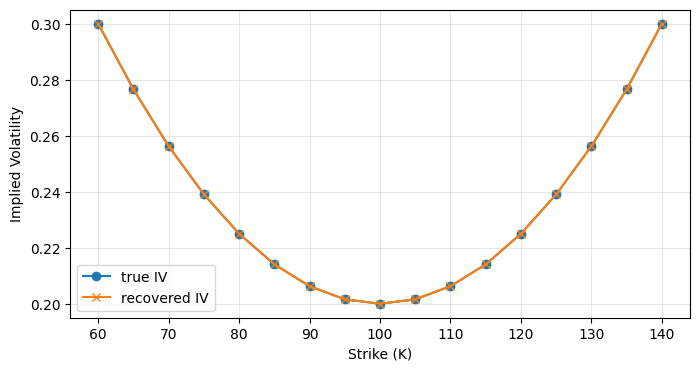

Ks.shape: (17,) prices.shape: (17,) true_sigma.shape: (17,) recovered_iv.shape: (17,)


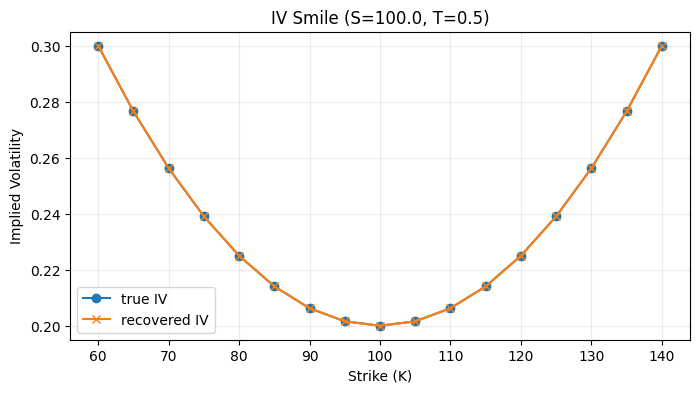

Saved plot to: notebooks\outputs\iv_smile.png


In [13]:
# IV smile example: create synthetic market prices then recover implied vol and plot
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Strike": Ks,
    "true_sigma": np.round(true_sigma, 6),
    "price": np.round(prices, 6),
    "implied_vol": np.round(recovered_iv, 6)
})

# Show table inside Jupyter
display(df)

# Plot the IV smile
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(Ks, true_sigma, marker="o", label="true IV")
ax.plot(Ks, recovered_iv, marker="x", label="recovered IV")
ax.set_xlabel("Strike (K)")
ax.set_ylabel("Implied Volatility")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


import os
import numpy as np
import matplotlib.pyplot as plt
from src.bsm.core import bsm_price, implied_vol

# ensure outputs folder exists under notebooks (the notebook expects notebooks/outputs)
out_dir = os.path.join("notebooks", "outputs")
os.makedirs(out_dir, exist_ok=True)

# ---- PARAMETERS (edit if you like) ----
S = 100.0       # spot price (scalar)
r = 0.01        # risk free
q = 0.0         # dividend yield
T = 0.5         # time to expiry (yrs)

# strike grid (17 points between 60 and 140)
Ks = np.linspace(60, 140, 17)

# define a "true" IV smile: ATM 0.20, wings +0.10 (parabolic)
true_sigma = 0.20 + 0.10 * ((Ks - S) / (S * 0.4))**2
true_sigma = np.clip(true_sigma, 0.01, 2.0)   # keep vols in a sane range

# ---- compute synthetic market prices (vectorized) ----
# bsm_price in our core supports numpy broadcasting; but ensure S broadcasts to Ks
S_arr = np.full_like(Ks, float(S), dtype=float)   # same shape as Ks
prices = bsm_price(S_arr, Ks, T, r, q, true_sigma, option="call")

# optional: tiny market noise (uncomment if you want)
# rng = np.random.default_rng(0)
# prices = prices + rng.normal(scale=1e-6, size=prices.shape)

# ---- recover implied vols vectorized ----
# implied_vol accepts arrays (mkt_price, S, K, T, r, q); call with S_arr and Ks
recovered_iv = implied_vol(prices, S_arr, Ks, T, r, q, option="call")

# convert to numpy array and make sure it matches Ks.shape
recovered_iv = np.asarray(recovered_iv).squeeze()
if recovered_iv.shape == ():
    # scalar -> replicate
    recovered_iv = np.full_like(Ks, float(recovered_iv), dtype=float)
else:
    # broadcast to Ks shape if possible
    try:
        recovered_iv = np.broadcast_to(recovered_iv, Ks.shape)
    except Exception:
        # last resort: flatten and if length matches Ks use it, otherwise repeat scalar
        recovered_iv = np.asarray(recovered_iv).ravel()
        if recovered_iv.size == 1:
            recovered_iv = np.full_like(Ks, float(recovered_iv[0]), dtype=float)
        elif recovered_iv.size == Ks.size:
            recovered_iv = recovered_iv.reshape(Ks.shape)
        else:
            # fallback: fill with NaNs so plot will show missing values
            recovered_iv = np.full_like(Ks, np.nan, dtype=float)

# ---- quick debug print (optional) ----
print("Ks.shape:", Ks.shape, "prices.shape:", prices.shape, "true_sigma.shape:", true_sigma.shape, "recovered_iv.shape:", recovered_iv.shape)

# ---- plot ----
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(Ks, true_sigma, label="true IV", marker="o")
ax.plot(Ks, recovered_iv, label="recovered IV", marker="x")
ax.set_xlabel("Strike (K)")
ax.set_ylabel("Implied Volatility")
ax.set_title(f"IV Smile (S={S}, T={T})")
ax.legend()
ax.grid(alpha=0.25)

# save to outputs and show inline
outfn = os.path.join(out_dir, "iv_smile.png")
fig.savefig(outfn, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot to:", outfn)
